In [96]:
import requests 
import numpy as np
import pandas as pd
import pprint
from bs4 import BeautifulSoup
headers = {
    "User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/122.0.0.0 Safari/537.36",
    "Accept-Language": "en-US,en;q=0.9"
}

In [97]:
male_url = "https://murderpedia.org/male.A/index.A.htm"
female_url = "https://murderpedia.org/female.A/index.A.htm"

male_response = requests.get(male_url, headers=headers)
female_response = requests.get(female_url, headers=headers)

male_soup = BeautifulSoup(male_response.text, "html.parser")
female_soup = BeautifulSoup(female_response.text, "html.parser")

male_response 
female_response

<Response [200]>

In [98]:
#I am first starting by adding the names, gender, victims, and location
#All of this information is from table 9 and from colums 1,3,4

from io import StringIO
import re

# Function to get victim tables
def get_victim_table(url, gender):
    html = requests.get(url, headers=headers).text
    tables = pd.read_html(StringIO(html))

    # Table 9 contains offender name, victims, and location
    df = tables[9][[1, 3, 4]]
    df.columns = ["name", "victims", "location"]

    # Removing the repeated header row/ without this the labels are wrong
    df = df.query("name != 'Name'")
    
#For all of the cleaning I am getting rid of spacing and formatting issues.
    # Cleaning names of offenders
    df["name"] = (df["name"].astype(str).str.replace(r"\s+", " ", regex=True).str.strip())

    # Cleaning victims
    df["victims"] = df["victims"].astype(str).str.strip()

    # Cleaning location
    df["location"] = ( df["location"].astype(str).str.replace(r"\s+", " ", regex=True).str.strip())

    # Adding gender
    df["gender"] = gender

    return df

# Creating male and female tables
male_table = get_victim_table("https://murderpedia.org/male.A/index.A.htm","Male")

female_table = get_victim_table(
    "https://murderpedia.org/female.A/index.A.htm",
    "Female"
)

# Combining male and female tables
victim_table = pd.concat([male_table, female_table], ignore_index=True)

# Combining victim/location/gender info with method info
final_df = victim_table.merge(
    final_df[["name", "method","gender", "location"]],
)

final_df[
    [
        "name",
        "gender",
        "victims",
        "location",
    ]
].head(270)

,name,gender,victims,location
0,Burton W. ABBOTT,Male,1,"California, USA"
1,Jack Henry ABBOTT,Male,2,"Utah/New York, USA"
2,William Keith ABBOTT,Male,1,New Zealand
3,Azad ABDULLAH,Male,1,"Idaho, USA"
4,Herisch Ali ABDULLAH,Male,1,Germany
...,...,...,...,...
249,Gunn-Britt ASHFIELD,Female,1,Australia
250,Lisl AUMAN,Female,1,"Colorado, USA"
251,Zakieya Latrice AVERY,Female,2,"Maryland, USA"
252,Asuncion AVILA-VILLA,Female,1,"Ohio, USA"


In [99]:
#Next I will be adding the methods each offender used

from urllib.parse import urljoin #https://docs.python.org/3/library/urllib.parse.html

# Making it into a dictionary so it's less lines
method_dict = { "Poisoning": ["poison", "arsenic", "cyanide"],
    "Shooting": ["shoot", "gun", "shot", "rifle"],
    "Stabbing": ["stab", "knife"],
    "Strangulation": ["strangl", "suffocat"],
    "Bludgeoning/Beating": ["bludgeon", "beat", "hammer", "club"],
    "Axe/Hatchet": ["axe", "hatchet"],
    "Drowning": ["drown"],
    "Burning/Fire": ["fire", "burn"]
}
# Creating a function to collect all offender profile links from the website while excluding index/navigation pages.
def get_methods(soup, url, df):
    links = [
        urljoin(url, tag["href"])
        for tag in soup.find_all("a", href=True)
        if tag["href"].endswith(".htm")
        and "index" not in tag["href"]
    ]
# Matching the number of offender to their method and then creating it as well

    links = links[:len(df)]
    methods = []

    for link in links:
        try:
            text = BeautifulSoup(
                requests.get(link, headers=headers).text,
                "html.parser"
            ).get_text(" ", strip=True).lower()

            method = next(
                (m for m, words in method_dict.items()
                 if any(word in text for word in words)),
                "Unknown"
            )

            methods.append(method)

        except:
            methods.append("Unknown")

    return methods, links

# Running for both male and female pages
male_methods, male_links = get_methods(male_soup, male_url, male_df)
female_methods, female_links = get_methods(female_soup, female_url, female_df)

# Adding methods to dataframes
male_df["method"] = male_methods
female_df["method"] = female_methods
#Seeing if all the numbers are the same 
print(len(male_df), len(male_links), len(male_methods))
print(len(female_df), len(female_links), len(female_methods))



220 220 220
50 50 50


In [100]:
# Combining methods with the other variables
victim_df = pd.concat([male_table, female_table],ignore_index=True)

# Creating dataframe with methods
method_df = pd.concat([male_df, female_df],ignore_index=True)

# Merging both together
final_df = victim_df.merge(method_df[["name", "method"]])

final_df[
    [
        "name",
        "gender",
        "victims",
        "location",
        "method",
    ]
].head(270)

,name,gender,victims,location,method
0,Burton W. ABBOTT,Male,1,"California, USA",Poisoning
1,Jack Henry ABBOTT,Male,2,"Utah/New York, USA",Stabbing
2,William Keith ABBOTT,Male,1,New Zealand,Shooting
3,Azad ABDULLAH,Male,1,"Idaho, USA",Stabbing
4,Herisch Ali ABDULLAH,Male,1,Germany,Shooting
...,...,...,...,...,...
249,Gunn-Britt ASHFIELD,Female,1,Australia,Shooting
250,Lisl AUMAN,Female,1,"Colorado, USA",Poisoning
251,Zakieya Latrice AVERY,Female,2,"Maryland, USA",Stabbing
252,Asuncion AVILA-VILLA,Female,1,"Ohio, USA",Bludgeoning/Beating


In [101]:
# Creating violent vs non-violent variable

violent_methods = ["Shooting", "Stabbing", "Strangulation","Bludgeoning/Beating", "Axe/Hatchet","Drowning", "Burning/Fire"]

final_df["violent_vs_nonviolent"] = ["Violent" if m in violent_methods else "Non-violent"for m in final_df["method"]]

final_df[
    [
        "name",
        "gender",
        "victims",
        "location",
        "method",
        "violent_vs_nonviolent"
    ]
].head(270)

,name,gender,victims,location,method,violent_vs_nonviolent
0,Burton W. ABBOTT,Male,1,"California, USA",Poisoning,Non-violent
1,Jack Henry ABBOTT,Male,2,"Utah/New York, USA",Stabbing,Violent
2,William Keith ABBOTT,Male,1,New Zealand,Shooting,Violent
3,Azad ABDULLAH,Male,1,"Idaho, USA",Stabbing,Violent
4,Herisch Ali ABDULLAH,Male,1,Germany,Shooting,Violent
...,...,...,...,...,...,...
249,Gunn-Britt ASHFIELD,Female,1,Australia,Shooting,Violent
250,Lisl AUMAN,Female,1,"Colorado, USA",Poisoning,Non-violent
251,Zakieya Latrice AVERY,Female,2,"Maryland, USA",Stabbing,Violent
252,Asuncion AVILA-VILLA,Female,1,"Ohio, USA",Bludgeoning/Beating,Violent


In [102]:
# Lastly I will be creating my second variable which identifies serial killer status
#According to the FBI a serial killer has to have 2 or more victims

# Creating serial killer variable
#Searching to see if the number or victims is 2 or more than labeling that as a Yes if it is just one then it will be a No

final_df["serial_killer"] = ["Yes" if re.search(r"\d+", str(v)) and int(re.search(r"\d+", str(v)).group()) >= 2
    else "No"
    for v in final_df["victims"]
]

final_df[
    [
        "name",
        "gender",
        "victims",
        "location",
        "method",
        "violent_vs_nonviolent",
        "serial_killer"
    ]
].head(270)

,name,gender,victims,location,method,violent_vs_nonviolent,serial_killer
0,Burton W. ABBOTT,Male,1,"California, USA",Poisoning,Non-violent,No
1,Jack Henry ABBOTT,Male,2,"Utah/New York, USA",Stabbing,Violent,Yes
2,William Keith ABBOTT,Male,1,New Zealand,Shooting,Violent,No
3,Azad ABDULLAH,Male,1,"Idaho, USA",Stabbing,Violent,No
4,Herisch Ali ABDULLAH,Male,1,Germany,Shooting,Violent,No
...,...,...,...,...,...,...,...
249,Gunn-Britt ASHFIELD,Female,1,Australia,Shooting,Violent,No
250,Lisl AUMAN,Female,1,"Colorado, USA",Poisoning,Non-violent,No
251,Zakieya Latrice AVERY,Female,2,"Maryland, USA",Stabbing,Violent,Yes
252,Asuncion AVILA-VILLA,Female,1,"Ohio, USA",Bludgeoning/Beating,Violent,No


In [103]:
#Grouping by location and gender and method to see if location impacts method
#But first I am going to make a USA variable since currently it shows up as states
final_df["usa_location"] = ["USA" if "USA" in location else "Non-USA" for location in final_df["location"]]

# Grouping USA vs Non-USA by gender and method type
usa_gender_method = (final_df.groupby(["usa_location", "gender", "method"]).size().reset_index(name="count"))

usa_gender_method
#For women not in the US their main method is posion while in the US it is shooting
#For maless regardless of location shooting is their main method

,usa_location,gender,method,count
0,Non-USA,Female,Bludgeoning/Beating,4
1,Non-USA,Female,Burning/Fire,1
2,Non-USA,Female,Poisoning,6
3,Non-USA,Female,Shooting,3
4,Non-USA,Female,Stabbing,5
5,Non-USA,Female,Unknown,1
6,Non-USA,Male,Bludgeoning/Beating,6
7,Non-USA,Male,Poisoning,6
8,Non-USA,Male,Shooting,25
9,Non-USA,Male,Stabbing,11


In [104]:
#Counting to see how many serial killers and non-serial killers there are by gender and location
#edit this info
final_df["usa_location"] = ["USA" if "USA" in location else "Non-USA" for location in final_df["location"]]
# Counting serial killers by location and gender
serial_by_location = (final_df.groupby(["usa_location", "gender", "serial_killer"])["name"].count().reset_index(name="count"))

serial_by_location
#There are more serial killers in the U.S for both genders

,usa_location,gender,serial_killer,count
0,Non-USA,Female,No,15
1,Non-USA,Female,Yes,5
2,Non-USA,Male,No,23
3,Non-USA,Male,Yes,33
4,USA,Female,No,20
5,USA,Female,Yes,10
6,USA,Male,No,80
7,USA,Male,Yes,68


In [105]:
# ROBUSTNESS CHECKS

# Checking for missing values
print("Missing Values")
print(final_df.isnull().sum())

# Checking for duplicate offender names
print("Duplicate Names")
print(final_df[final_df.duplicated(subset="name", keep=False)])

# Checking category counts
print("Gender Counts")
print(final_df["gender"].value_counts())

print("Location Counts")
print(final_df["usa_location"].value_counts())

print("Method Counts")
print(final_df["method"].value_counts())

print("Violent vs Non-Violent Counts")
print(final_df["violent_vs_nonviolent"].value_counts())

print("Serial Killer Counts")
print(final_df["serial_killer"].value_counts())

# Checking location by gender
print("USA vs Non-USA by Gender")
print(final_df.groupby(["usa_location", "gender"])["name"].count().reset_index(name="count"))

# Summary statistics
print("Summary Statistics")
print(final_df.describe(include="all"))

Missing Values
name                     0
victims                  0
location                 0
gender                   0
method                   0
violent_vs_nonviolent    0
serial_killer            0
usa_location             0
dtype: int64
Duplicate Names
Empty DataFrame
Columns: [name, victims, location, gender, method, violent_vs_nonviolent, serial_killer, usa_location]
Index: []
Gender Counts
gender
Male      204
Female     50
Name: count, dtype: int64
Location Counts
usa_location
USA        178
Non-USA     76
Name: count, dtype: int64
Method Counts
method
Shooting               136
Stabbing                50
Poisoning               31
Bludgeoning/Beating     16
Strangulation           13
Unknown                  5
Burning/Fire             2
Drowning                 1
Name: count, dtype: int64
Violent vs Non-Violent Counts
violent_vs_nonviolent
Violent        218
Non-violent     36
Name: count, dtype: int64
Serial Killer Counts
serial_killer
No     138
Yes    116
Name: count, dt

In [106]:
print(final_df.columns)

Index(['name', 'victims', 'location', 'gender', 'method',
       'violent_vs_nonviolent', 'serial_killer', 'usa_location'],
      dtype='object')


In [107]:
final_df.to_csv("murderpedia_updated.csv", index=False)

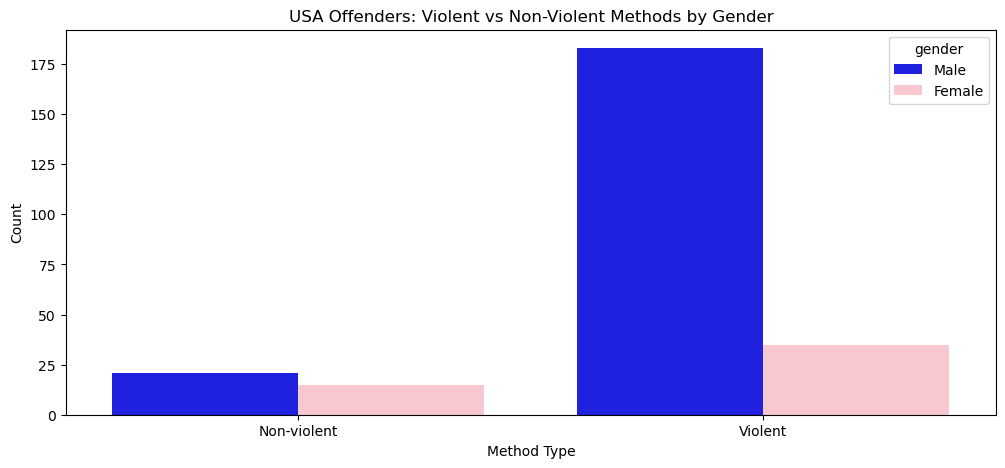

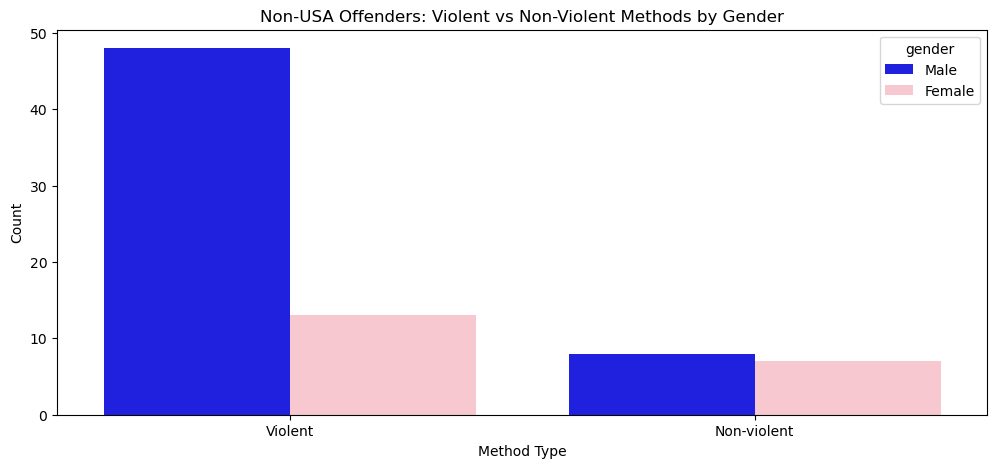

In [108]:
# My first graph will show Violent vs Non-Violent Methods by Gender and Location

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

sns.countplot(data=final_df, x="violent_vs_nonviolent", hue="gender",palette={"Male": "blue", "Female": "pink"})

plt.title("USA Offenders: Violent vs Non-Violent Methods by Gender")
plt.xlabel("Method Type")
plt.ylabel("Count")
plt.savefig("Violent_Location_GenderUSA", dpi=300, bbox_inches="tight")
plt.show()

# Non-USA Graph
plt.figure(figsize=(12,5))

sns.countplot(data=final_df[final_df["usa_location"] == "Non-USA"],x="violent_vs_nonviolent",hue="gender",palette={"Male": "blue", "Female": "pink"})

plt.title("Non-USA Offenders: Violent vs Non-Violent Methods by Gender")
plt.xlabel("Method Type")
plt.ylabel("Count")
plt.savefig("Violent_Location_Gender", dpi=300, bbox_inches="tight")
plt.show()
#Regardless of location and Gender the most common method is violent

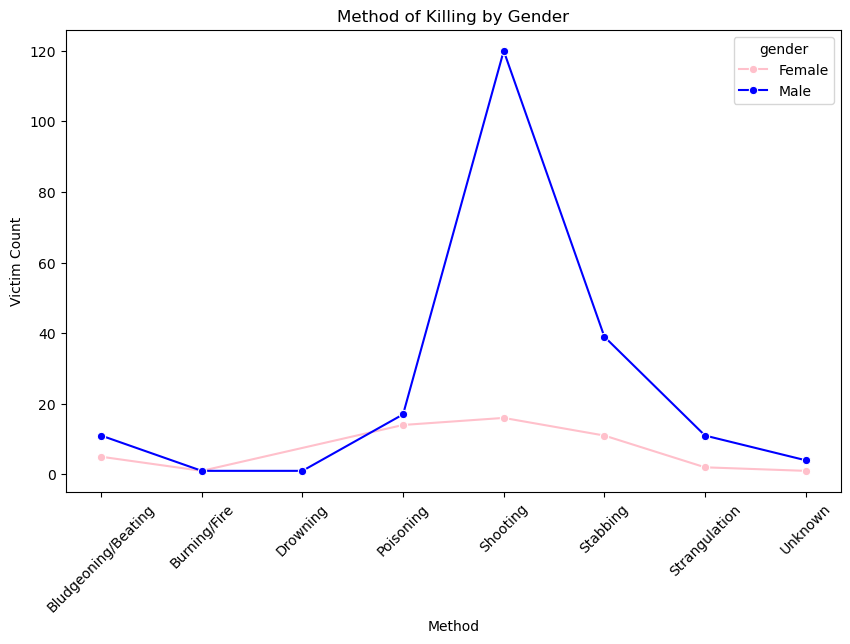

In [109]:
#My second graph is method of killing by gender and will be a line graph 
method_gender = ( final_df.groupby(["method", "gender"]).size().reset_index(name="count"))

plt.figure(figsize=(10,6))

sns.lineplot(data=method_gender,x="method",y="count",hue="gender",palette={"Male": "blue", "Female": "pink"},marker="o")

plt.title("Method of Killing by Gender")
plt.xlabel("Method")
plt.ylabel("Victim Count")

plt.xticks(rotation=45)
plt.savefig("method_vic.png", dpi=300, bbox_inches="tight")
plt.show()